# ch303 — Multilayer Networks

## 1. Stacking layers to break linearity

XOR cannot be solved by a single linear boundary *(demonstrated in ch302)*. The solution
is to compose two linear transformations with a nonlinearity between them. The intermediate
layer learns a new **representation** in which the data becomes linearly separable.

A two-layer network solving XOR:
1. Layer 1 maps the 2D input into a 2D hidden space via a learned linear transform + nonlinearity.
2. Layer 2 classifies in that hidden space.

The hidden layer's job is to find coordinates where the problem is easy. This is the essence
of representation learning.

---

## 2. Formal definition

An $L$-layer feedforward network computes:

$$
a^{[0]} = x
$$
$$
z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]}, \quad l = 1, \ldots, L
$$
$$
a^{[l]} = \sigma^{[l]}(z^{[l]})
$$
$$
\hat{y} = a^{[L]}
$$

where $W^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}$, $b^{[l]} \in \mathbb{R}^{n_l}$,
and $\sigma^{[l]}$ is the activation function at layer $l$.

The total parameter count is $\sum_{l=1}^L (n_l \cdot n_{l-1} + n_l)$.

*(Matrix multiplication shapes reviewed in ch153–ch155. Notation defined in ch301.)*

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def relu(z):
    return np.maximum(0, z)


class MLP:
    """
    Minimal multilayer perceptron — forward pass only.
    layer_sizes: list of ints, e.g. [2, 4, 1] for 2-in, 4-hidden, 1-out.
    """

    def __init__(self, layer_sizes: list, activation=sigmoid, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.params = []
        self.activation = activation
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            # Xavier initialisation (covered fully in ch308)
            scale = np.sqrt(2.0 / (fan_in + fan_out))
            W = rng.normal(0, scale, (fan_out, fan_in))
            b = np.zeros(fan_out)
            self.params.append((W, b))

    def forward(self, x: np.ndarray) -> tuple:
        """Forward pass. Returns (output, list of (z, a) per layer)."""
        a = x
        cache = []
        for i, (W, b) in enumerate(self.params):
            z = W @ a + b
            # Last layer: sigmoid for binary output; hidden layers: chosen activation
            a_new = sigmoid(z) if i == len(self.params) - 1 else self.activation(z)
            cache.append((z, a_new))
            a = a_new
        return a, cache

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.forward(x)[0] for x in X]).squeeze()


# --- Manually set weights that solve XOR exactly ---
# XOR: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0
# Hidden layer computes: (x OR y) and NOT (x AND y)
net = MLP([2, 2, 1])
# Layer 1: detect (x+y > 0.5) and (x+y > 1.5)
net.params[0] = (
    np.array([[20., 20.], [20., 20.]]),   # W1
    np.array([-10., -30.])               # b1
)
# Layer 2: (h1 - h2)
net.params[1] = (
    np.array([[20., -20.]]),             # W2
    np.array([-10.])                     # b2
)

X_xor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = np.array([0, 1, 1, 0])

print("XOR solved with 2-2-1 network:")
for xi, yi in zip(X_xor, y_xor):
    out, _ = net.forward(xi)
    out_val = out.item()
    print(f"  Input {xi.astype(int)} → output {out_val:.4f} → predicted {int(out_val > 0.5)} (true {yi})")

print("\nNetwork architecture:")
for l, (W, b) in enumerate(net.params):
    print(f"  Layer {l+1}: W shape {W.shape}, b shape {b.shape}, "
          f"params = {W.size + b.size}")

XOR solved with 2-2-1 network:
  Input [0 0] → output 0.0000 → predicted 0 (true 0)
  Input [0 1] → output 1.0000 → predicted 1 (true 1)
  Input [1 0] → output 1.0000 → predicted 1 (true 1)
  Input [1 1] → output 0.0000 → predicted 0 (true 0)

Network architecture:
  Layer 1: W shape (2, 2), b shape (2,), params = 6
  Layer 2: W shape (1, 2), b shape (1,), params = 3


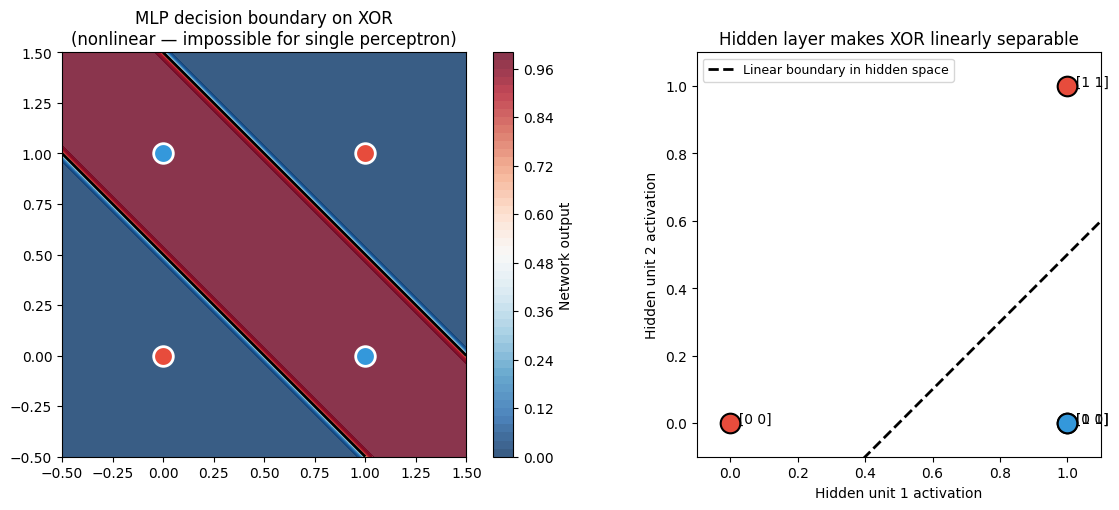

In [6]:
# Visualise the decision boundary of the XOR-solving network
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = net.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision boundary
ax = axes[0]
cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.8)
plt.colorbar(cf, ax=ax, label='Network output')
ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
colors = ['#e74c3c', '#3498db']
for cls in [0, 1]:
    mask = y_xor == cls
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], color=colors[cls],
               s=200, zorder=5, edgecolors='white', linewidths=2)
ax.set_title('MLP decision boundary on XOR\n(nonlinear — impossible for single perceptron)')
ax.set_aspect('equal')

# Hidden layer representations
ax2 = axes[1]
h_reprs = []
for xi in X_xor:
    _, cache = net.forward(xi)
    h_reprs.append(cache[0][1])  # a^[1]: hidden activation
h_reprs = np.array(h_reprs)

for cls in [0, 1]:
    mask = y_xor == cls
    ax2.scatter(h_reprs[mask, 0], h_reprs[mask, 1], color=colors[cls],
                s=200, zorder=5, edgecolors='black', linewidths=1.5)
    for i, (xi, label) in enumerate(zip(h_reprs[mask], X_xor[mask])):
        ax2.annotate(f'  {label.astype(int)}', xi, fontsize=10)

xx2 = np.linspace(-0.1, 1.1, 200)
W2, b2 = net.params[1]
if abs(W2[0, 1]) > 1e-8:
    yy2 = -(W2[0, 0] * xx2 + b2[0]) / W2[0, 1]
    ax2.plot(xx2, yy2, 'k--', lw=2, label='Linear boundary in hidden space')

ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.set_title('Hidden layer makes XOR linearly separable')
ax2.set_xlabel('Hidden unit 1 activation')
ax2.set_ylabel('Hidden unit 2 activation')
ax2.legend(fontsize=9)
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('ch303_mlp_xor.png', dpi=120)
plt.show()

## 3. What the hidden layer does

The right panel above shows the XOR inputs mapped into the hidden layer's coordinate system.
In the original space, the two classes are diagonally arranged (not separable).
In the hidden space, they become linearly separable — the layer 2 perceptron can solve it.

This is the core mechanism of deep learning: **each layer learns to represent the world
in a coordinate system that makes the remaining problem easier**.

---

## 4. Parameter count and capacity

Adding depth is not the only way to increase capacity — you can also increase width.
But depth is more parameter-efficient for hierarchical structure:

| Architecture | Params | Notes |
|---|---|---|
| [2, 100, 1] | 401 | Wide, shallow |
| [2, 10, 10, 1] | 141 | Deeper, fewer params |
| [2, 4, 4, 4, 1] | 61 | Even deeper |

For structured tasks (images, sequences), deep = better. For tabular data, the advantage
of depth shrinks considerably.

---

## 5. The complete computation graph

```
x ──→ [W1, b1] ──→ z1 ──→ σ ──→ a1 ──→ [W2, b2] ──→ z2 ──→ σ ──→ ŷ ──→ Loss
                                                                           ↓
                                                              Gradients flow backward
```

This graph is the blueprint for backpropagation *(ch306)*.

---

## 6. Summary

- Stacking layers composes linear transformations with nonlinearities, creating nonlinear classifiers.
- Hidden layers learn representations: new coordinate systems where the problem is easier.
- The computation follows a clean forward pass: input → pre-activations → activations → output.
- Depth increases capacity more efficiently than width for hierarchically structured problems.

---

## 7. Forward and backward references

**Used here:** matrix multiplication *(ch153–ch155)*, function composition *(ch054)*,
perceptron geometry *(ch302)*, sigmoid *(ch064)*.

**This will reappear in ch304 — Forward Pass**, where the computation is vectorised across
batches of samples, and in ch306 — Backpropagation, where we reverse the computation
graph to compute gradients.